# Student FULL name: Prajwal Shrestha
# Student number: 49188658

Acknowledgement Statement by students: <br>
Please keep one acknowledgment from the following<br>
	I acknowledge that I have not used GenAI (e. g., ChatGPT) in drafting and proofreading of this assignment.<br>
	I acknowledge that I have only used GenAI (e.g., ChatGPT) in drafting and proofreading this assignment, which is permitted in the assignment instructions. <br>



#  Answer to Section 1 (answer in the below cell, please do not add more cells): 

## Diamond industry in Australia (3 facts along with its source)

1. Australia's first major diamond discovery was the Argyle deposit in the Kimberley region, with indicator minerals found in January 1973 and production starting in 1983. Source: Development of Australia's first major diamond discovery outlined

2. Argyle became one of the world's most important diamond mines and was developed under a formal state agreement in Western Australia in 1981. Source: the Western Australian Diamond (Argyle Diamond Mines Joint Venture) Agreement Act 1981.

3. Maureen Muggeridge is credited with tracing diamond samples back to the Argyle source. He was the first one to discover it in Australia. Source: https://www.brilliyond.com.au/education/diamond-mining/australia

# Answer to Section 2: add as many cell as needed 

In [108]:
# importing necessary libraries for data manipulation

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [109]:
# Load the CSV file into the pandas DataFrame

diamond = pd.read_csv("Assignment_BUSA8000_data.csv")
print('Dataset loaded successfully')

Dataset loaded successfully


In [110]:
# Displaying the first 5 rows of the DataFrame to have a quick view of the data structure and
# sample values

diamond.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.34,Good,Z,SI2,62.2,59,4.35,4.34,2.7,349
1,0.21,Premium,E,SI1,59.8,61,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58,4.2,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58,4.34,4.35,2.75,335


In [111]:
# Generating descriptive stats for going through basic stats rundown

diamond.describe()

,y
count,55842.000000
mean,5.746221
std,1.164288
min,0.000000
25%,4.720000
50%,5.710000
75%,6.550000
max,58.900000


In [112]:
# Figuring out how many rows and columns I am working with

diamond.shape

(55843, 10)

In [113]:
# Figuring out how many null values we have in the each column

diamond.isnull().sum()

carat      0
cut        2
color      0
clarity    1
depth      2
table      1
x          1
y          1
z          0
price      2
dtype: int64

In [114]:
# Cleaning the data using dropna() so that we can maintain data integrity, and simplify analysis

diamond = diamond.replace(['na', '', ' ', '  '], float('nan')).dropna()

In [115]:
# Checking if the null values were dropped and identifying how many rows are left

diamond.shape

(55809, 10)

In [116]:
# Final check of null values in dataset

diamond.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [117]:
# Validating the dtypes before proceeding further in EDA

diamond.dtypes

carat       object
cut         object
color       object
clarity     object
depth       object
table       object
x           object
y          float64
z           object
price       object
dtype: object

In [118]:
# Categorizing columns to convert the datatypes into its actual dtype for further EDA

float_cols = ['carat', 'depth', 'x', 'y', 'z', 'table']
diamond[float_cols] = diamond[float_cols].astype('float64')

# int64 — via float64 first to handle decimal strings like '55.3'
int_cols = ['price']
diamond[int_cols] = diamond[int_cols].astype('int64')

In [119]:
# Validating if the datatype has been converted

diamond.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
x          float64
y          float64
z          float64
price        int64
dtype: object

In [120]:
# Checking if there are any duplicate values in the dataset. The duplicated() function used here is
# identifying duplicate rows in our data and sum is summing all the count of True values.

num_duplicates = diamond.duplicated().sum()
print(f'There are {num_duplicates} duplicated values')

There are 147 duplicated values


In [121]:
# Dropping rows where the rows are same but keeping the one of it within the dataset

if num_duplicates > 0:
    display(diamond[diamond.duplicated(keep='first')])

,carat,cut,color,clarity,depth,table,x,y,z,price
1005,0.79,Ideal,G,SI1,62.3,57.0,5.90,5.85,3.66,2898
1006,0.79,Ideal,G,SI1,62.3,57.0,5.90,5.85,3.66,2898
1007,0.79,Ideal,G,SI1,62.3,57.0,5.90,5.85,3.66,2898
1008,0.79,Ideal,G,SI1,62.3,57.0,5.90,5.85,3.66,2898
2025,1.52,Good,E,I1,57.3,58.0,7.53,7.42,4.28,3105
...,...,...,...,...,...,...,...,...,...,...
49334,0.51,Ideal,F,VVS2,61.2,56.0,5.17,5.19,3.17,2093
49565,0.71,Good,F,SI2,64.1,60.0,0.00,0.00,0.00,2130
50087,0.51,Ideal,F,VVS2,61.2,56.0,5.19,5.17,3.17,2203
52869,0.50,Fair,E,VS2,79.0,73.0,5.21,5.18,4.09,2579


In [122]:
# I am checking if there are any values less than 0 here because I saw that there were 0 in x, y, z

(diamond[['x','y','z']] <= 0).sum()

x     9
y     8
z    21
dtype: int64

In [123]:
# Dropping any rows that has values less than 0 in x, y, z

diamond = diamond[(diamond['x'] > 0) & (diamond['y'] > 0) & (diamond['z'] > 0)]

In [124]:
# Final validation of data after dropping any values that are less than 0 in x, y, z

(diamond[['x','y','z']] <= 0).sum()

x    0
y    0
z    0
dtype: int64

In [125]:
# I am checking how many duplicates does each of the categories contains so that I can keep the first one and deleting the other
# duplicates for futher visualization.

duplicate_counts = (
    diamond.groupby(list(diamond.columns))
      .size()
      .reset_index(name='count')
      .query('count > 1')
      .sort_values('count',
                   ascending=False)
      .reset_index(drop=True)
)

print(f"Number of unique records that are duplicated: {len(duplicate_counts)}\n")
print("Duplicate frequency breakdown:")
display(duplicate_counts)

Number of unique records that are duplicated: 143

Duplicate frequency breakdown:


,carat,cut,color,clarity,depth,table,x,y,z,price,count
0,0.79,Ideal,G,SI1,62.3,57.0,5.90,5.85,3.66,2898,5
1,0.23,Ideal,J,VS1,62.8,56.0,3.93,3.90,2.46,340,2
2,1.00,Ideal,I,SI2,58.8,55.0,6.53,6.46,3.82,3629,2
3,1.00,Premium,F,VVS2,60.6,54.0,6.56,6.52,3.96,8924,2
4,1.00,Premium,G,SI1,60.1,61.0,6.44,6.40,3.86,3634,2
...,...,...,...,...,...,...,...,...,...,...,...
138,0.36,Ideal,D,SI1,62.7,57.0,4.54,4.59,2.86,663,2
139,0.36,Ideal,D,SI1,62.7,57.0,4.59,4.54,2.86,851,2
140,0.40,Ideal,G,VVS1,62.3,54.0,4.75,4.76,2.96,1043,2
141,0.40,Ideal,J,VVS2,61.8,55.0,4.76,4.79,2.95,662,2


In [126]:
# Dropping all the duplicates whilst keeping the first data in the dataset so that it reflects true dataset.

diamond = diamond.drop_duplicates(keep='first')
diamond.reset_index(drop=True, inplace=True)

In [127]:
# After cleaning the data, checking each category to understand how diamonds are distributed
# Helps me understand the inventories stocked by Aurora Diamonds

print("cut distribution:\n", diamond['cut'].value_counts())
print("\nclarity distribution:\n", diamond['clarity'].value_counts())
print("\ncolor distribution:\n", diamond['color'].value_counts())

cut distribution:
 cut
Ideal        21893
Premium      14148
Very Good    12434
Good          5229
Fair          1934
Very Fair        2
Name: count, dtype: int64

clarity distribution:
 clarity
SI1     13269
VS2     12454
SI2      9377
VS1      8382
VVS2     5316
VVS1     3884
IF       2005
I1        953
Name: count, dtype: int64

color distribution:
 color
G    11248
E     9770
F     9511
H     8257
D     6749
I     5401
J     2802
Z     1900
S        1
N        1
Name: count, dtype: int64


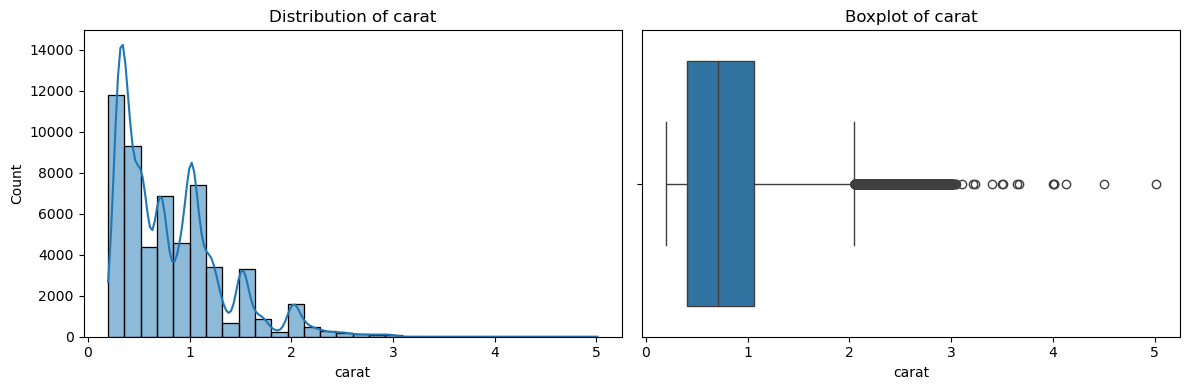

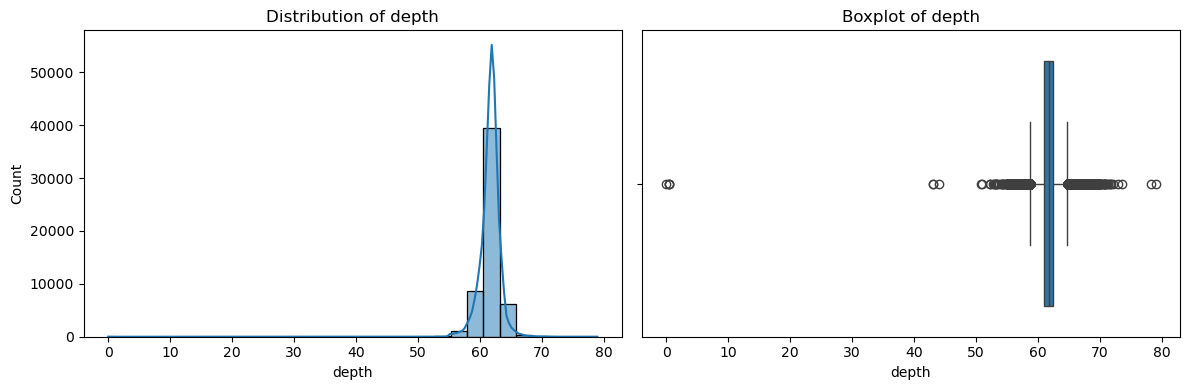

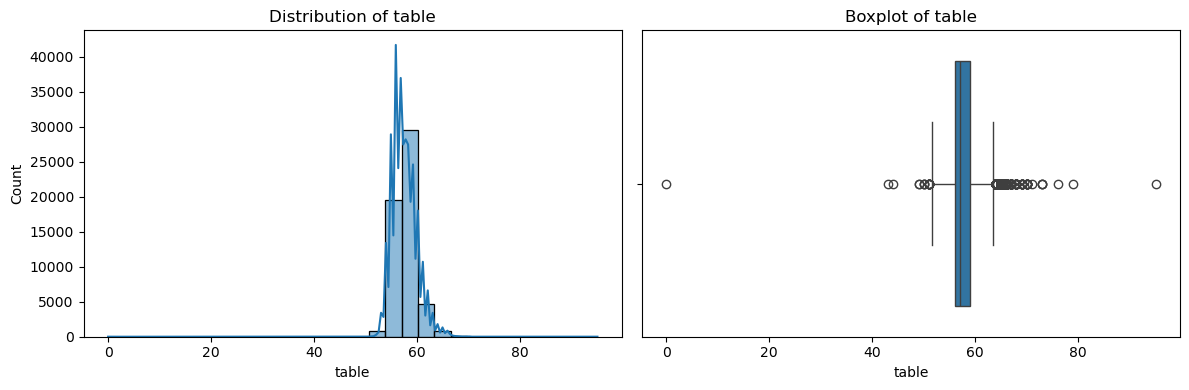

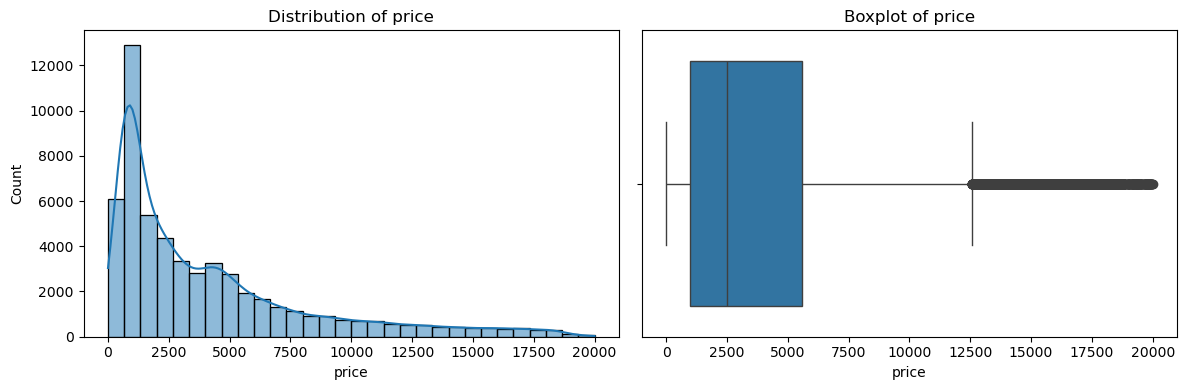

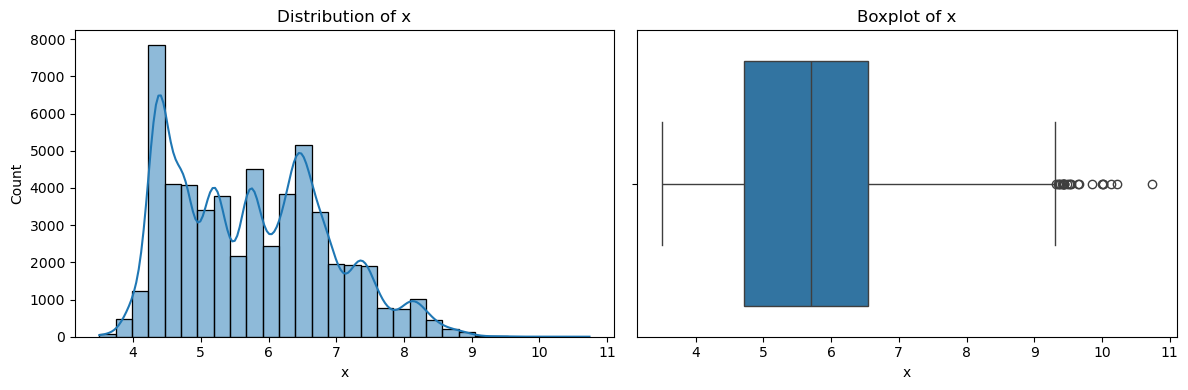

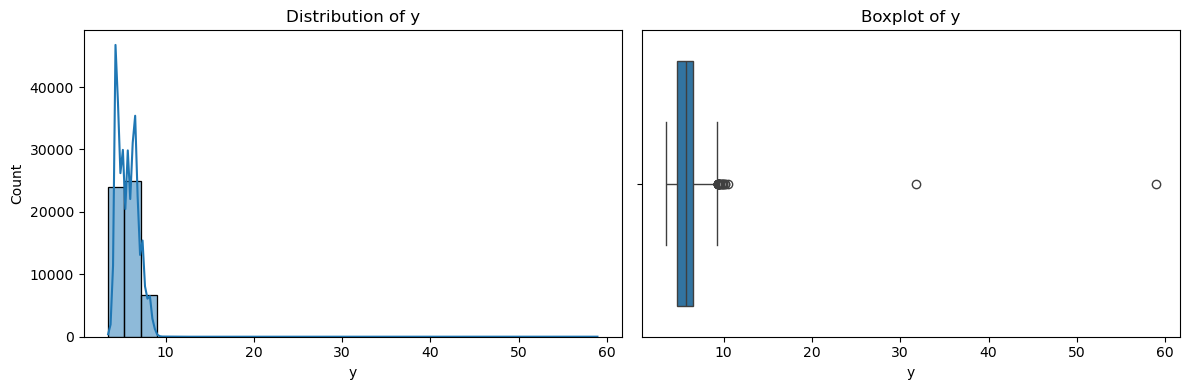

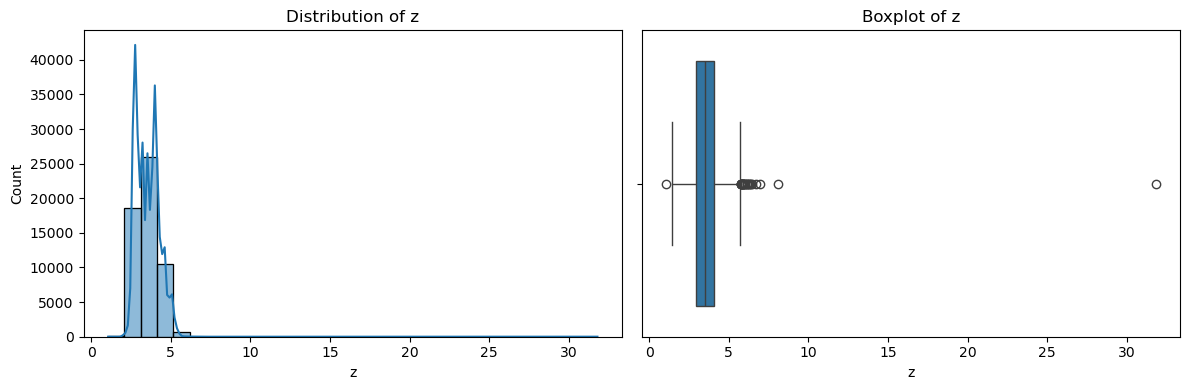

In [128]:
# Analyzing two plots (histogram and box plot) to help me decide whether a variable needs further cleaning before visualization.

numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize = (12, 4))
    
    sns.histplot(diamond[col], bins = 30, kde = True, ax = axes[0])
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')

    sns.boxplot(x = diamond[col], ax = axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

#### Carat
- Upon the analysis of Carat, The distribution is right skewed, which means the majority of diamonds are under 1 carat, with very few large diamonds above 3 carats.
- The boxplot shows that there are several outliers on the upper end; more than 2 carats.

Upon further study, I found that this anomaly is quite common in the real diamond market where large diamonds are rare and expensive.

#### Depth
- Upon analysis of Depth, The distrbution seems to have a normal distrbution which is tightly centered around 61% to 62%
- The boxplot suggests that there are extreme outliers on both ends; values near 0 and above 75 are physically unrealistic for the cut diamond.

#### Table
- Upon the analysis of Table, it is also normally distributed and concentrated between 54–62.
- The boxplot shows a small number of outliers on both ends; values near 0 and above 90 are unrealistic and likely errors.

However, most of the data are usable and well-behaved.

#### Price
- Price is strongly right-skewed; most diamonds are priced under $2,500 but a long tail extends to $20,000.
- The boxplot shows a large number of high-price outliers beyond the upper whisker.

#### x(width)
- Width shows a multimodal distribution with several peaks, suggesting diamonds cluster around certain standard sizes.
- The boxplot shows a few high-end outliers above 9mm which are unusually large diamonds.

#### y(length)
- The distribution appears similar to x but the boxplot reveals two extreme outliers far to the right (around 30–60mm).
- These values are almost certainly data errors; a diamond 60mmlong would be extraordinarily large and inconsistent with the rest of the dataset.

#### z(height)
- Similar pattern to y; mostly concentrated between 2–5mm but the boxplot shows one extreme outlier near 32mm.
- A diamond 32mm tall is not physically consistent with the x and y values in this dataset and is almost certainly a data entry error.

### Before proceeding to visualization, checking final descriptive stats

In [131]:
print("Final descriptive statistics after all cleaning steps:\n")
display(diamond.describe().round(2))

# Also confirm final shape of the cleaned DataFrame
print(f"\nFinal DataFrame shape: {diamond.shape}")
print(f"Total missing values : {diamond.isnull().sum().sum()}")
print(f"Duplicate rows       : {diamond.duplicated().sum()}")

Final descriptive statistics after all cleaning steps:



,carat,depth,table,x,y,z,price
count,55640.00,55640.00,55640.00,55640.00,55640.00,55640.00,55640.00
mean,0.82,61.69,57.52,5.74,5.75,3.55,4129.21
std,0.51,1.61,2.35,1.14,1.16,0.72,4199.18
min,0.20,0.00,0.00,3.50,3.50,1.07,0.00
25%,0.40,61.00,56.00,4.71,4.72,2.91,965.00
50%,0.71,61.80,57.00,5.70,5.71,3.53,2513.00
75%,1.06,62.50,59.00,6.55,6.55,4.04,5606.25
max,5.01,79.00,95.00,10.74,58.90,31.80,19996.00



Final DataFrame shape: (55640, 10)
Total missing values : 0
Duplicate rows       : 0


In [132]:
# Count how many diamonds fall into each grade for cut, color, and clarity
# This tells us if the dataset is balanced or skewed toward certain categories
# which is important context for interpreting any categorical visualizations

categorical_cols = ['cut', 'color', 'clarity']

for col in categorical_cols:

    # Get counts and percentage share for each category
    counts = diamond[col].value_counts()
    pct    = (diamond[col].value_counts(normalize=True) * 100).round(2)

    # Combine into a readable summary table
    summary = pd.DataFrame({
        'count'  : counts,
        'percent': pct
    })

    print(f"Value counts — {col}:")
    print(summary.to_string())
    print("-" * 35)

Value counts — cut:
           count  percent
cut                      
Ideal      21893    39.35
Premium    14148    25.43
Very Good  12434    22.35
Good        5229     9.40
Fair        1934     3.48
Very Fair      2     0.00
-----------------------------------
Value counts — color:
       count  percent
color                
G      11248    20.22
E       9770    17.56
F       9511    17.09
H       8257    14.84
D       6749    12.13
I       5401     9.71
J       2802     5.04
Z       1900     3.41
S          1     0.00
N          1     0.00
-----------------------------------
Value counts — clarity:
         count  percent
clarity                
SI1      13269    23.85
VS2      12454    22.38
SI2       9377    16.85
VS1       8382    15.06
VVS2      5316     9.55
VVS1      3884     6.98
IF        2005     3.60
I1         953     1.71
-----------------------------------


Correlation matrix:


,carat,depth,table,price,x,y,z
carat,1.00,-0.03,0.20,0.86,0.89,0.86,0.87
depth,-0.03,1.00,-0.27,-0.06,-0.03,-0.04,0.07
table,0.20,-0.27,1.00,0.15,0.19,0.18,0.14
price,0.86,-0.06,0.15,1.00,0.82,0.81,0.80
x,0.89,-0.03,0.19,0.82,1.00,0.92,0.92
y,0.86,-0.04,0.18,0.81,0.92,1.00,0.89
z,0.87,0.07,0.14,0.80,0.92,0.89,1.00


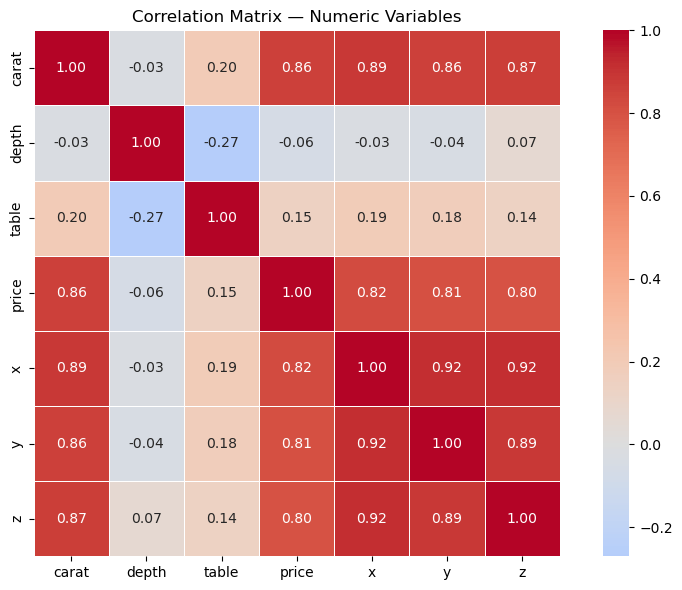

In [133]:
# Compute pairwise correlation between all numeric columns
# Correlation ranges from -1 (perfect negative) to +1 (perfect positive)
# Values close to 0 indicate little to no linear relationship
# This is to identify:
# - Which variables are most strongly related to price
# - Multicollinearity between x, y, z and carat (expected to be high
#   since they all measure physical size)

numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

# Compute the correlation matrix using the diamond DataFrame
corr_matrix = diamond[numeric_cols].corr().round(2)

print("Correlation matrix:")
display(corr_matrix)

# Plot as a heatmap for easier visual interpretation
plt.figure(figsize=(9, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.show()

## Correlation Matrix — Interpretation

### Strong Positive Correlations with Price
- carat vs price (0.86); the strongest driver of price. As diamond weight increases, price increases significantly. This is the most important relationship in the dataset.
- x vs price (0.82), y vs price (0.82), z vs price (0.81) — all three physical dimensions are strongly correlated with price, which makes sense because a larger diamond in any dimension will also weigh more (higher carat) and therefore cost more.

### Multicollinearity — carat, x, y, z
- carat vs x (0.89), carat vs y (0.88), carat vs z (0.88) — these are extremely high correlations, confirming that carat weight and physical dimensions are essentially measuring the same thing — the overall size of the diamond.
- x vs y (0.94), x vs z (0.93), y vs z (0.92) — the three dimensions are almost perfectly correlated with each other.
- This means x, y, z and carat carry redundant information. In any future regression model, using all four together would cause multicollinearity issues — ideally only carat would be kept as the size representative.

### Weak or Negligible Correlations
- depth vs price (-0.06) — depth has almost no relationship with price. A diamond's depth percentage does not meaningfully influence its market value.
- table vs price (0.15) — table percentage has only a very weak positive relationship with price, suggesting it is not a key price driver either.
- depth vs carat (-0.03) — essentially zero correlation, confirming depth and size are independent characteristics.

### Negative Correlation
- depth vs table (-0.29) — a moderate negative relationship, meaning diamonds with a larger table percentage tend to have a smaller depth percentage. This reflects a known trade-off in diamond cutting — cutters balance table width against depth to optimise brilliance. 

### Overall Summary
 - Carat is the primary diver of the price
 - sizes drives price indiretly via carat
 - depth and price have no meaningful relationship
 - table and price have a very weak relationship

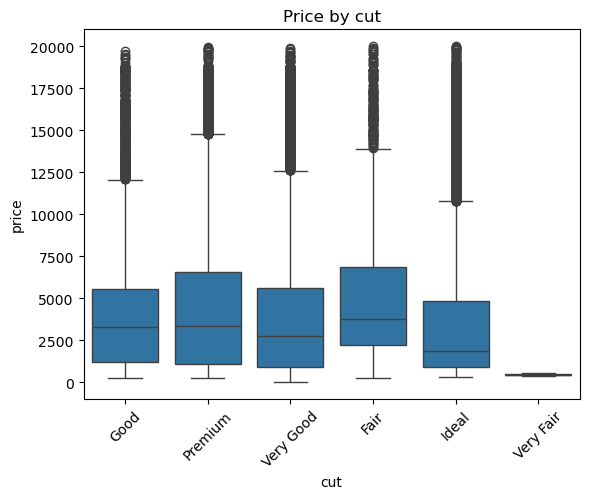

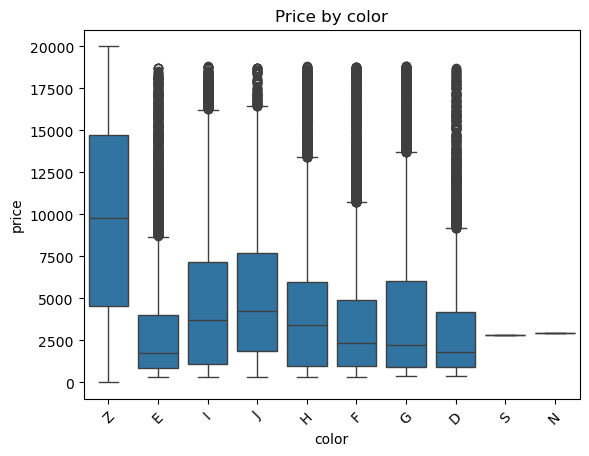

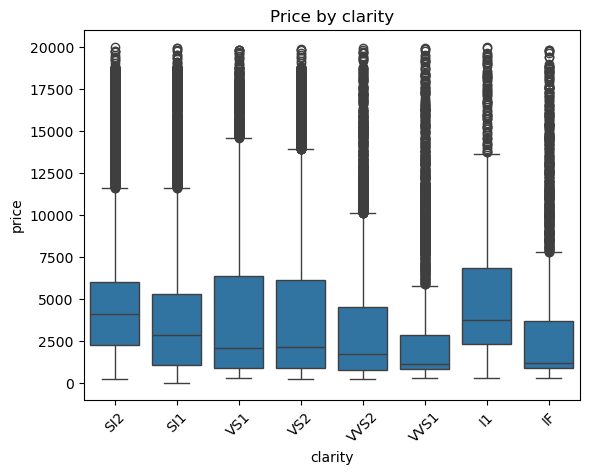

In [135]:
# Checking how price varies across different categories.

categorical_cols = ['cut', 'color', 'clarity']

for col in categorical_cols:
   plt.figure()
   sns.boxplot(x=col, y='price', data=diamond)
   plt.title(f'Price by {col}')
   plt.xticks(rotation=45)
   plt.show()


## Interpretation of relationship between categorical values and price

#### Color represented in symbol has its own meaning as per GIA Diamond Color Scale found in: https://4cs.gia.edu/en-us/diamond-color/

### Price
The chart suggest, Ideal cut diamonds do not command the highest prices, fiar and Premium cut diamonds actually show higher median prices. In the diagram, all cut categories show a large number of high-price outliers, confirming the right-skewed nature of price seen earlier.

### Color
z and j color (mostly yellow) diamonds tend to have higher median prices than d and e (most colorless/best). This suggests lower color grade diamonds in the dataset tend to be larger in carat weight, whihc pushes their price up despite poorer color quality.

s and n color grades appear to have very few observations.

### Clarity:
Clarity shows SI2 and SI1 (Lower quality) show relatively higher median prices than VVS1 and IF (higher quality)

# Answer to Section 3 - one cell per visualisation, please add one comment before each code explaining what does the visulisaiton tend to present

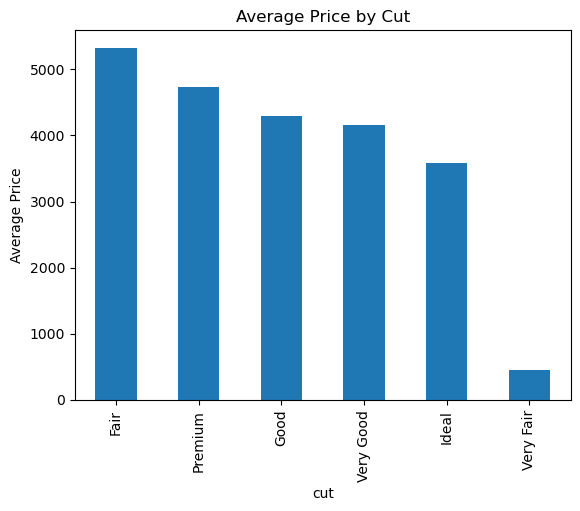

In [138]:
# Visualizing which cut has the highest average price

cut_price = diamond.groupby('cut')['price'].mean().sort_values(ascending = False)

cut_price.plot(kind = 'bar')
plt.title('Average Price by Cut')
plt.ylabel('Average Price')
plt.show()

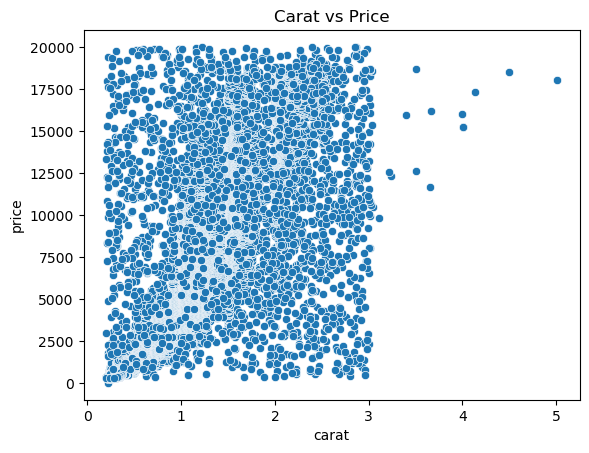

In [139]:
# Visualizing how the carat affects the price of the diamonds

sns.scatterplot(data = diamond, x = 'carat', y = 'price')
plt.title('Carat vs Price')
plt.show()

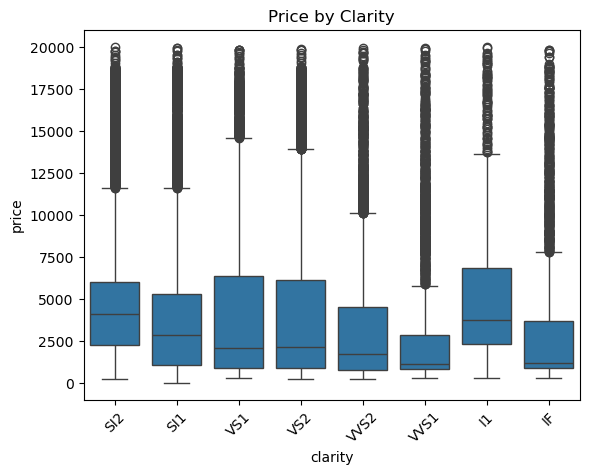

In [140]:
# Visualizing how the Clarity affects the price of the diamond

sns.boxplot(data = diamond, x = 'clarity', y = 'price')
plt.title('Price by Clarity')
plt.xticks(rotation = 45)
plt.show()

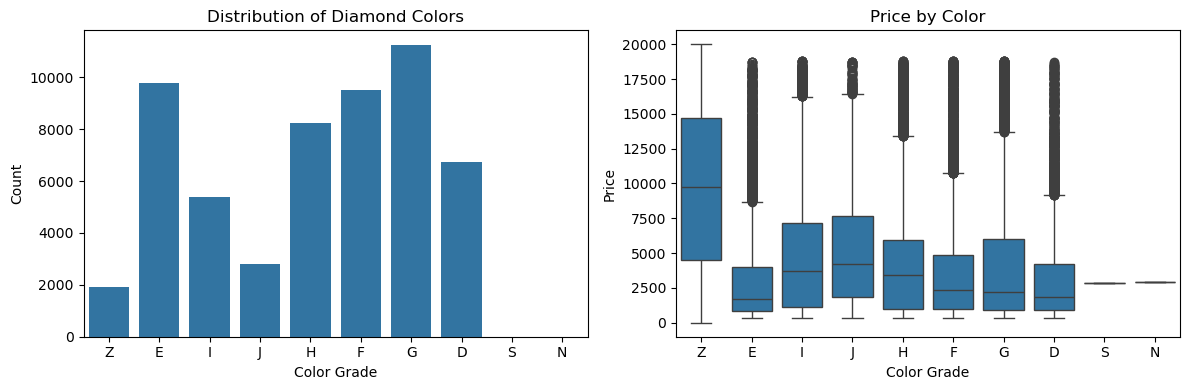

In [141]:
# Visualizing how color distribution and price vary

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
    
sns.countplot(data = diamond, x = 'color', ax = axes[0])
axes[0].set_title("Distribution of Diamond Colors")
axes[0].set_xlabel('Color Grade')
axes[0].set_ylabel('Count')

sns.boxplot(data = diamond, x = 'color', y = 'price', ax = axes[1])
axes[1].set_title("Price by Color")
axes[1].set_xlabel('Color Grade')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

# Answer to Section 4, two cells per test

In [143]:
# Test 1: One-Sample T-Test

# Goal: Test whether the mean price of diamonds is significantly different from the median of the dataset

# Rationale: Our histogram showed price is right skewed, meaning the mean and median are likely different.
# This test confirms whether that difference is statistically significant

# Using the dataset's median as the benchmark to avoid external assumption
benchmark_price = diamond['price'].median()

# Extracting the price column as the sample
sample_price = diamond['price']

# Setting the hypothesis

# H0: Mean price = Median price (distribution is symmetrical)
# H1: Mean price ≠ median price (distribution is not symmetrical)

# Running the one sample t-test:
t_stat, p_value = stats.ttest_1samp(sample_price, popmean = benchmark_price)


print('Test 1: One Sample T-Test')

print(f'Sample mean price:  {sample_price.mean():,.2f}')
print(f'Median (benchmark): {benchmark_price:,.2f}')
print(f'Difference: {sample_price.mean() - benchmark_price:,.2f}')
print(f't-statistics: {t_stat:,.4f}')
print(f'p-value: {p_value:,.4f}')
print()
if p_value < 0.05:
    print(f'''Result: Reject H0 - The mean is significantly different from the median ({benchmark_price:,.3f}), confirming
    the right-skewed distribution observed in the histogram (p < 0.05)''')
else:
    print(f'Result: Fail to reject H0 - No significant diffence between mean and median price (p >= 0.05)')

Test 1: One Sample T-Test
Sample mean price:  4,129.21
Median (benchmark): 2,513.00
Difference: 1,616.21
t-statistics: 90.7879
p-value: 0.0000

Result: Reject H0 - The mean is significantly different from the median (2,513.000), confirming
    the right-skewed distribution observed in the histogram (p < 0.05)


## Test 1 Result Interpretation

The mean is significantly higher than the median, confirming the distribution is heavily right-skewed.

## What this means for the business?
1. The majority of diamonds are priced below $ 2,513 (median) which means, Aurora Gems should use the median as the reference point for the customer facing communications rather than mean.
   
2. Revenue is largely driven by a small number of expensive stones suggesting that the small number of very high-priced diamonds are pulling the average up. So, for Aurora, losing even few high-value sales could significantly impact the top line.

In [145]:
# Test 2: Two-Sample T-Test (Two-Sided)
# Goal: Test whether Ideal cut and Fair cut diamonds have significantly different prices without assuming which group is more expensive

# Rationale: Our boxplot analysis showed a counterintuitive relationship between cut quality and price. 
# This test formally confirms whether the price difference between the best cut (Ideal) and worst cut (Fair)
# is statistically significant in either direction.

# Extract price for each group
ideal_prices = diamond[diamond['cut'] == 'Ideal']['price']
fair_prices  = diamond[diamond['cut'] == 'Fair']['price']

# Setting the hypothesis

# H0: Mean price of Ideal cut = Mean price of Fair (no difference)
# H1: Mean price of Ideal cut ≠ Mean price of Fair (significant difference)

# Printing the group sizes and means before running the test
print(f'Ideal cut count: {len(ideal_prices):,} mean: {ideal_prices.mean():,.2f}')
print(f'Fair cut count: {len(fair_prices):,} mean: {fair_prices.mean():,.2f}')

# Running the independet samples t-test (two-sided)
t_stat2, p_value2 = stats.ttest_ind(ideal_prices, fair_prices, equal_var = False, alternative = 'two-sided')

print()
print("Test 2: Two-Sample T-Test (Two-Sided)")
print(f"Ideal cut mean price: ${ideal_prices.mean():,.2f}")
print(f"Fair cut mean price: ${fair_prices.mean():,.2f}")
print(f"Difference: ${ideal_prices.mean() - fair_prices.mean():,.2f}")
print(f"T-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.4f}")
print()
if p_value2 < 0.05:
    print(f'Result: Reject H0 — There IS a significant price difference between Ideal and Fair cut diamonds (p < 0.05)')
else:
    print(f'Result: Fail to reject H0 — No significant price difference between Ideal and Fair cut diamonds (p >= 0.05)')

Ideal cut count: 21,893 mean: 3,583.72
Fair cut count: 1,934 mean: 5,324.16

Test 2: Two-Sample T-Test (Two-Sided)
Ideal cut mean price: $3,583.72
Fair cut mean price: $5,324.16
Difference: $-1,740.43
T-statistic: -16.4448
P-value: 0.0000

Result: Reject H0 — There IS a significant price difference between Ideal and Fair cut diamonds (p < 0.05)


## Test 2 Result Interpretation

Even though there is statistically significant price different between Ideal and Fair Cut diamonds, the direction is
counter-intuitive. This is because, fair cut diamonds are on average $ 1740.43 more expensive than the Ideal cut diamonds.
This directly contradicts the expectation that better cut quality commands higher price.

This contradiction was identified in our EDA wherein fair cut diamonds in the dataset tend to be larger in carat weight and since
carat weight is the strongest predictor of price a large fair cut diamond will cost more than a small ideal cut diamond.

## What this means for Aurora?
1. Aurora should not assume that stocking higher cut quality diamonds will automatically generate higher revenue
   
2. A fair cut diamond priced at $ 5,342 on average will generate significantly more reveneu per stone than an Ideal cut diamond
at 3,583 dollars; the owner should prioritise carat weight over cut grade in inventory when maximizing per unit economics.

3. During sourcing, Aurora should consider large carat diamonds as they may be available at lower wholesale cost while still commanding high retail prices due to their weight.

In [99]:
# Test 3: Two-Sample T-Test (Upper-Tailed)
# Goal: Test whether IF (Internally Flawless) clarity diamonds cost significantly MORE than I1 (Most Included) clarity diamonds

# Rationale: The GIA clarity scale ranks IF as the highest clarity grade and I1 as the lowest. Domain knowledge strongly predicts
# that flawless diamonds should command higher prices — making this a clear directional hypothesis suitable for a one-tailed test.

# Setting the hypothesis:

# H0: Mean price of IF <= Mean price of I1 (IF is not more expensive)
# H1: Mean price of IF >  Mean price of I1 (IF costs significantly MORE)
# Test type: Upper-tailed (alternative='greater')

# Extract price for each clarity group
IF_prices = diamond[diamond['clarity'] == 'IF']['price']
I1_prices = diamond[diamond['clarity'] == 'I1']['price']

# Print group sizes and means before running the test
print(f"IF clarity count: {len(IF_prices):,}  mean: ${IF_prices.mean():,.2f}")
print(f"I1 clarity count: {len(I1_prices):,}  mean: ${I1_prices.mean():,.2f}")

# Run the independent samples t-test (upper-tailed)

t_stat3, p_value3 = stats.ttest_ind(IF_prices, I1_prices, equal_var=False, alternative='greater')

print()
print("Test 3: Two-Sample T-Test (Upper-Tailed)")
print(f"IF clarity mean price : ${IF_prices.mean():,.2f}")
print(f"I1 clarity mean price : ${I1_prices.mean():,.2f}")
print(f"Difference: ${IF_prices.mean() - I1_prices.mean():,.2f}")
print(f"T-statistic: {t_stat3:.4f}")
print(f"P-value: {p_value3:.4f}")
print()
if p_value3 < 0.05:
    print("Result: Reject H0 — IF clarity diamonds cost significantly more than I1 clarity diamonds (p < 0.05)")
else:
    print("Result: Fail to reject H0 — IF clarity diamonds do not cost significantly more than I1 diamonds (p >= 0.05)")

IF clarity count: 2,005  mean: $3,670.89
I1 clarity count: 953  mean: $5,426.97

Test 3: Two-Sample T-Test (Upper-Tailed)
IF clarity mean price : $3,670.89
I1 clarity mean price : $5,426.97
Difference: $-1,756.08
T-statistic: -9.7293
P-value: 1.0000

Result: Fail to reject H0 — IF clarity diamonds do not cost significantly more than I1 diamonds (p >= 0.05)


### Test 3 Result Interpretation

A p-value of exactly 1 in an upper tailed test is a strong signal that the data is moving in the opposite direction to what was hypothesized. The test reveals that there is no probability of IF being more expensive, but opposite is true.

What seems so fascinating is that all the 3 test that was conducted points to the same conclusion: carat weight is so dominant that it reveses the expected relationships between quality grades and price.

### What it means for Aurora Gems?
1. Clarity grade is not a reliable pricing signal so, carat weight must be taken into account first and then quality after that.
2. If Aurora Gems have heavily invested in IF clarity inventory assuming premium pricing, this data suggests they may struggle to achive expected margins.


## My final verdict
1. I would suggest Aurora Gems to build their business around carat weight first.
2. I would suggest them to use quality grades (cut, color, clarity) as secondary this is because, sourcing diamonds based primarily on these factors risks systematic mispricing and missed revenue opportunities.